In [1]:
import pandas as pd
df = pd.read_excel("reconcile/storage/output/clean_output_ben.xlsx")

# what logic to we apply to dates & ramp-ups

In [5]:
df = df[df["gwh_normalized"] == True].copy()
df['value_gwh_normalized'] = pd.to_numeric(df['value_gwh_normalized'], errors='coerce')

df_unique = df.groupby(["inst_canon", "adm1", "product_lv1", "status", "phase"]).agg({
    'product_lv2': 'unique',
    'capacity': 'unique',
    'article_id': 'unique',
    'adm2': 'first',
    'iso2': 'first'
}).reset_index()

In [6]:
df_unique

,inst_canon,adm1,product_lv1,status,phase,product_lv2,capacity,article_id,adm2,iso2
0,acc,Hauts-de-France,battery,announced,expansion,[nan],[120 GWh],[67f921ccf431fddd61d55c4c],Pas-de-Calais,FR
1,acc,Rheinland-Pfalz,battery,announced,expansion,[nan],[120 GWh],[67f921ccf431fddd61d55c4c],None,DE
2,acc,Rheinland-Pfalz,battery,announced,greenfield,[cell],[24 GWh],[67f92128f431fddd61d55a28],None,DE
3,aesc,England,battery,announced,expansion,[cell],"[16 GWh, 35 GWh]","[682cb737d0a7623114bd9778, 67f92187f431fddd61d...",Sunderland,GB
4,aesc,England,battery,announced,greenfield,[cell],[9 GWh],[67f92187f431fddd61d55b67],Sunderland,GB
...,...,...,...,...,...,...,...,...,...,...
374,volvo northvolt,Västra Götaland,battery,under construction,greenfield,[cell],[50 GWh],[67f52c98981040986eab79af],Gothenburg Municipality,SE
375,volvo northvolt,Västra Götaland,vehicle,announced,greenfield,[electric],[50 GWh],[67f52bc2981040986eab7659],Gothenburg Municipality,SE
376,wanxiang group,Zhejiang,battery,announced,greenfield,[nan],[80 GWh],[67f920f6f431fddd61d5597f],Hangzhou Shi,CN
377,west midlands gigafactory,England,battery,announced,greenfield,[cell],[60 GWh],"[67f921aef431fddd61d55bea, 67f52cd7981040986ea...",Coventry,GB


In [34]:
df_unique[df_unique["iso2"] == "PL"]

,inst_canon,adm1,product_lv1,status,phase,product_lv2,value_gwh_normalized,article_id,iso2
222,lg energy solution,Lower Silesia,battery,operational,unclear,[module_pack],70.0,[67f92299f431fddd61d55ef1],PL
351,umicore,Opole Voivodeship,battery,announced,expansion,[eam],100.0,"[67f92248f431fddd61d55de2, 67f92212f431fddd61d...",PL
352,umicore,Opole Voivodeship,battery,operational,greenfield,[eam],20.0,[67f92248f431fddd61d55de2],PL


In [29]:
df_unique.to_excel("unique.xlsx")

In [ ]:
## Battery cell by country
df_cell = df[(df["product_lv1"] == "battery") & (df["product_lv2"] == "cell")].copy()

df_cell_facility = df_cell.groupby(["inst_canon", "adm1", "product_lv1", "status", "phase"]).agg({
    'value_gwh_normalized': 'mean',
    'article_id': 'unique',
    'iso2': 'first'
}).reset_index()

df_cell_country = df_cell_facility.groupby(["iso2","status"]).agg({
    'value_gwh_normalized': 'sum'
}).reset_index()


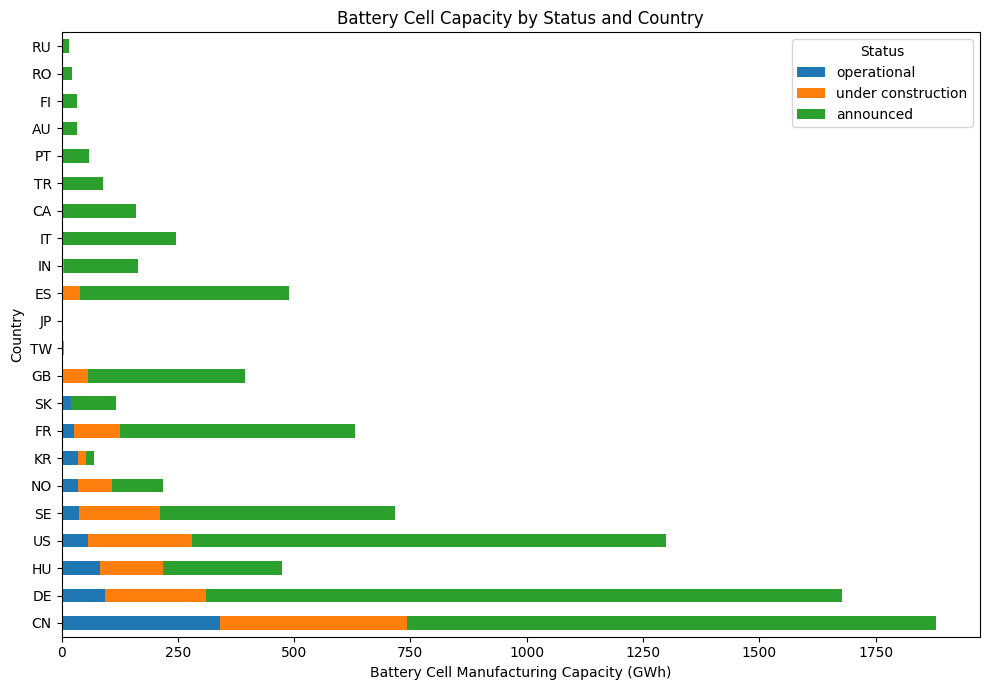

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure correct ordering of statuses
status_order = ["operational", "under construction", "announced"]

# Pivot data to wide format
df_plot = df_cell_country.pivot(index="iso2", columns="status", values="value_gwh_normalized").fillna(0)

# Reorder columns to match desired stack order
df_plot = df_plot[status_order]

# Sort by total capacity (optional, for better visual)
df_plot = df_plot.sort_values(by=status_order, ascending=False)

# Plot
df_plot.plot(kind='barh', stacked=True, figsize=(10, 7))

plt.xlabel("Battery Cell Manufacturing Capacity (GWh)")
plt.ylabel("Country")
plt.title("Battery Cell Capacity by Status and Country")
plt.legend(title="Status")
plt.tight_layout()
plt.show()